# Nivel 1 

#### 1. Importación de datos

In [134]:
import pandas as pd
from datetime import datetime


In [135]:

def load_and_validate_data():
    df = pd.read_excel('sprint10.xlsx', header=3)
    
    df.sort_values(by=['País d\'origen', 'Ciutat'], inplace=True)
    
    print("Comprobación de unicidad del DNI:")
    print(f"Registros totales: {len(df)}")
    print(f"DNI único: {df['DNI'].nunique()}")
    print(f"Los DNI son únicos: {df['DNI'].nunique() == len(df)}")
    
    return df



In [136]:
df = load_and_validate_data()
df.head(10)

Comprobación de unicidad del DNI:
Registros totales: 1000
DNI único: 1000
Los DNI son únicos: True


,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B



#### 2. Transformación y normalización de DF 

In [137]:
def transform_columns(df):

    df['Nom complet'] = df['Nom'].astype(str) + ' ' + df['Cognoms'].astype(str)
    
    df['Lugar de nacimiento Espanya'] = df["País d'origen"] == "Espanya"

    df = df.set_index('DNI')

    df.rename(columns={
        'Unnamed: 0': 'ID',
        'Dia de Naixement': 'Dia',
        'Mes de Naixement': 'Mes', 
        'Any de Naixement': 'Any',
        'Salari mensual': 'Salari mensual €',
    }, inplace=True)
    
    df.replace({
        'Gènere': {
            'H': 'Home',
            'D': 'Dona',
            'A': 'Altres',
            'NC': None
        }
    }, inplace=True)
    
    df['Salari mensual €'] = df['Salari mensual €'].str.rstrip('€').str.replace(' ', '').str.replace('.', '').astype(float)
    
    return df


In [138]:
df = transform_columns(df)
df.head()

,ID,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual €,Fills,No Fills,Grup Professional,Nom complet,Lugar de nacimiento Espanya
DNI,,,,,,,,,,,,,,,
28973553Z,21,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.0,NaN,1.0,Grup A,Mia Schneider Fischer,False
37399141L,154,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.0,1.0,NaN,Grup B,Laura Schneider Fischer,False
37368317L,224,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.0,NaN,1.0,Grup B,Lea Schneider Schneider,False
21390098Z,278,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.0,1.0,NaN,Grup B,Mia Fischer,False
44060014R,602,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.0,1.0,NaN,Grup D,Jonas Schneider,False


#### 3. Información sobre hijos

In [139]:
def process_children_columns(df):

    def determine_children(row):
        if pd.notna(row['Fills']) and row['Fills'] == 1.0:
            return 'Sí'
        elif pd.notna(row['No Fills']) and row['No Fills'] == 1.0:
            return 'No'
        else:
            return 'No especificado'
    
    df['Hijos'] = df.apply(determine_children, axis=1)
    df.drop(['Fills', 'No Fills'], axis=1, inplace=True)
    
    return df


In [140]:
df = process_children_columns(df)
df.head(10)

,ID,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual €,Grup Professional,Nom complet,Lugar de nacimiento Espanya,Hijos
DNI,,,,,,,,,,,,,,
28973553Z,21,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.0,Grup A,Mia Schneider Fischer,False,No
37399141L,154,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.0,Grup B,Laura Schneider Fischer,False,Sí
37368317L,224,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.0,Grup B,Lea Schneider Schneider,False,No
21390098Z,278,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.0,Grup B,Mia Fischer,False,Sí
44060014R,602,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.0,Grup D,Jonas Schneider,False,Sí
14773153R,871,Lea,Fischer,Alemanya,Berlín,9,9,1986,Dona,1370.0,Grup A,Lea Fischer,False,Sí
23266650S,281,Lea,Müller,Alemanya,Hamburg,14,4,2003,Dona,1314.0,Grup A,Lea Müller,False,No
83274277X,435,Anna,Müller,Alemanya,Hamburg,1,1,1987,Dona,2464.0,Grup C,Anna Müller,False,No
60161784X,444,Laura,Schmidt Müller,Alemanya,Hamburg,15,6,1987,None,2035.0,Grup C,Laura Schmidt Müller,False,Sí


#### 4. Datos estáticos por género del empleado

In [141]:
def salary_statistics_by_gender(df):
    
    stats = df.groupby('Gènere')['Salari mensual €'].agg([
        ('Media', 'mean'),
        ('Mediana', 'median'),
        ('Mínimo', 'min'),
        ('Máximo', 'max')
    ]).round(2)
    
    stats = stats.sort_values('Media', ascending=False)
    
    return stats


In [142]:
stats_df = salary_statistics_by_gender(df)
stats_df.head()

,Media,Mediana,Mínimo,Máximo
Gènere,,,,
Home,1643.25,1531.0,737.0,3356.0
Altres,1626.59,1545.0,703.0,3175.0
Dona,1469.44,1361.5,665.0,3021.0



#### 5. Resumen por género y país

In [143]:
def pivot_table_with_formatting(df):

    pivot_df = df.pivot_table(
        index='Gènere',
        columns='País d\'origen', 
        values='Salari mensual €',
        aggfunc='mean',
        margins=True,
        margins_name='Media Total'
    ).round(2)

    return pivot_df


In [144]:
pivot_table = pivot_table_with_formatting(df)

pivot_table.head()

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Media Total
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Media Total,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


In [145]:
import numpy as np

In [146]:
def highlight_max(x, color):
    return np.where(x == np.nanmax(x.to_numpy()), f"color: {color};", None)

In [147]:
def highlight_min(x, color):
    return np.where(x == np.nanmin(x.to_numpy()), f"color: {color};", None)

In [148]:
pivot_table.style.apply(highlight_max, color='green').apply(highlight_min, color='red')

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Media Total
Gènere,,,,,,,,,,,
Altres,951.000000,1141.000000,1030.000000,1706.180000,nan,1423.000000,1365.000000,1372.000000,1765.000000,1921.000000,1626.590000
Dona,1804.310000,1291.800000,1497.750000,1460.160000,1566.470000,1247.180000,1405.210000,1517.800000,1488.550000,1489.460000,1469.440000
Home,2067.430000,1583.290000,1554.670000,1682.110000,1389.250000,1672.880000,1531.000000,1625.000000,1497.000000,1162.560000,1643.250000
Media Total,1851.380000,1463.390000,1495.540000,1581.210000,1462.730000,1425.950000,1447.330000,1558.420000,1523.330000,1423.560000,1560.990000


#### 6. Fecha de nacimiento y edad

In [149]:
def process_dates_and_age(df):

    df['Fecha de nacimiento'] = pd.to_datetime({
        'year': df['Any'],
        'month': df['Mes'], 
        'day': df['Dia']
    })

    def calculate_age(birth_date):
        today = datetime.now()
        age = today.year - birth_date.year
        if (today.month, today.day) < (birth_date.month, birth_date.day):
            age -= 1
        return age
    
    df['Edad'] = df['Fecha de nacimiento'].apply(calculate_age)
    
    df.drop(['Any', 'Mes', 'Dia'], axis=1, inplace=True)
    
    return df


In [150]:
df = process_dates_and_age(df)
df[['Fecha de nacimiento', 'Edad']].head()

,Fecha de nacimiento,Edad
DNI,,
28973553Z,1976-10-22,48
37399141L,1958-02-02,67
37368317L,2005-10-23,19
21390098Z,1950-08-11,75
44060014R,1985-11-22,39


# Nivel 2

#### 1. Aumento de salario

In [151]:
def apply_salary_increment(df):

    df_increment = pd.DataFrame({
        "Grup": ["Grup A", "Grup B", "Grup C", "Grup D"],
        "Increment": ["5%", "3,5%", "2%", "8%"]
    })
    df_increment.rename(columns={'Grup': 'Grup Professional'}, inplace=True)
    
    df = df.merge(df_increment, on='Grup Professional', how='left')
    
    df['Salari mensual €'] = df['Salari mensual €'] * (
        1 + df['Increment']
          .str.replace(',', '.')
          .str.rstrip('%')
          .astype(float)
          .div(100)
    )
    
    df.drop('Increment', axis=1, inplace=True)
    
    return df

In [152]:
df = apply_salary_increment(df)
df[['Grup Professional', 'Salari mensual €']].head()

,Grup Professional,Salari mensual €
0,Grup A,998.550
1,Grup B,1830.915
2,Grup B,2083.455
3,Grup B,1611.495
4,Grup D,2974.320


#### 2. Exportación de datos

In [157]:
def export_data_by_group(df):
    groups = ['Grup A', 'Grup B', 'Grup C', 'Grup D']
    
    for group in groups:
        group_data = df[df['Grup Professional'] == group]
        filename = f"datos_{group.replace(' ', '')}.xlsx"
        group_data.to_excel(filename, index=True)
        print(f"Archivo guardado exitosamente:{filename}")
        

    statistics_df = df.groupby('Grup Professional').agg({
        'ID': 'count',
        'Salari mensual €': 'mean',
        'Edad': 'median'
    }).round(2)
    
    statistics_df.rename(columns={
        'Id': 'Cantidad de trabajadores',
        'Salari mensual €': 'Salario medio', 
        'Edad': 'Edad mediana'
    }, inplace=True)
    
    statistics_df.to_excel('estadisticas_empleados.xlsx')
    
    return statistics_df

In [158]:
employee_stats = export_data_by_group(df)
employee_stats.head()

Archivo guardado exitosamente:datos_GrupA.xlsx
Archivo guardado exitosamente:datos_GrupB.xlsx
Archivo guardado exitosamente:datos_GrupC.xlsx
Archivo guardado exitosamente:datos_GrupD.xlsx


,ID,Salario medio,Edad mediana
Grup Professional,,,
Grup A,490,1213.32,50.0
Grup B,318,1724.55,47.0
Grup C,137,2289.19,51.0
Grup D,55,3100.82,43.0


# Nivel 3 

#### Función de procesamiento de datos para visualización


In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def auto_visualize_dataframe(df):
    Path("auto_plots").mkdir(exist_ok=True)
    
    for column in df.columns:
        
        if pd.api.types.is_numeric_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            sns.histplot(df[column], kde=True)
            plt.title(f"Distribución {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")
            plt.savefig(f"auto_plots/{column}_numeric.png")
            plt.show()
        
        elif pd.api.types.is_string_dtype(df[column]) or pd.api.types.is_categorical_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            df[column].value_counts().head(10).plot(kind='bar')
            plt.title(f"Categorías principales {column}")
            plt.xlabel(column)
            plt.ylabel("Número")
            plt.savefig(f"auto_plots/{column}_categorical.png")
            plt.show()
        
        elif pd.api.types.is_datetime64_any_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            df[column].dt.year.value_counts().sort_index().plot(kind='bar')
            plt.title(f"Número por año ({column})")
            plt.xlabel("Año")
            plt.ylabel("Número")
            plt.savefig(f"auto_plots/{column}_datetime.png")
            plt.show()
            

### Error con importación del paquete seaborn con un DF "iris"

En el ejercicio se dice: "Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic." Pero intentando descargar un archivo de seaborn sale un error de certificados SSL: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>

Intente resolverlo con instalacion de certificados y tambien con reinstalacion seaborn y con deshabilitacion de verificación SSL, pero no funcionaba nada de estos intentas. 
#### Por eso tenemos un acuerdo: 
mostrar como funcciona auto_visualize_dataframe(df) en un DF descargado y leido de PATH o en un DF que ya he usado para Nivel 1 y Nivel 2 

In [156]:

import ssl
import certifi

import seaborn as sns
df = sns.load_dataset("iris")
df.head()

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>

In [ ]:
df = sns.load_dataset("iris")
df

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>

### Acuerdo

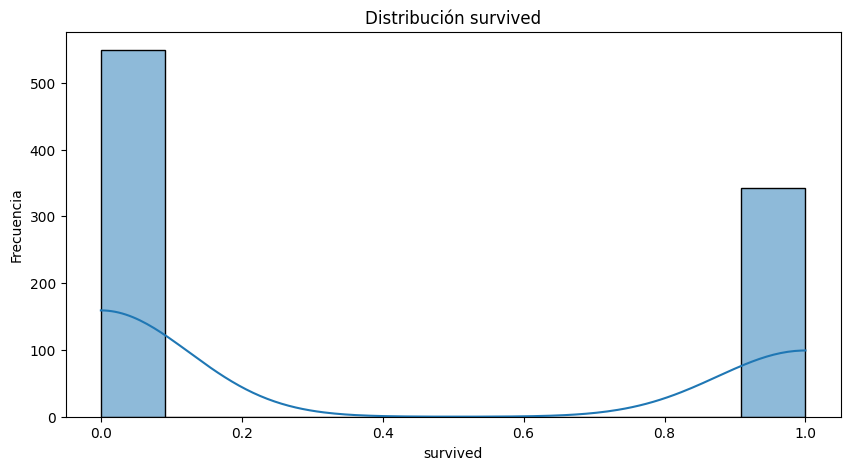

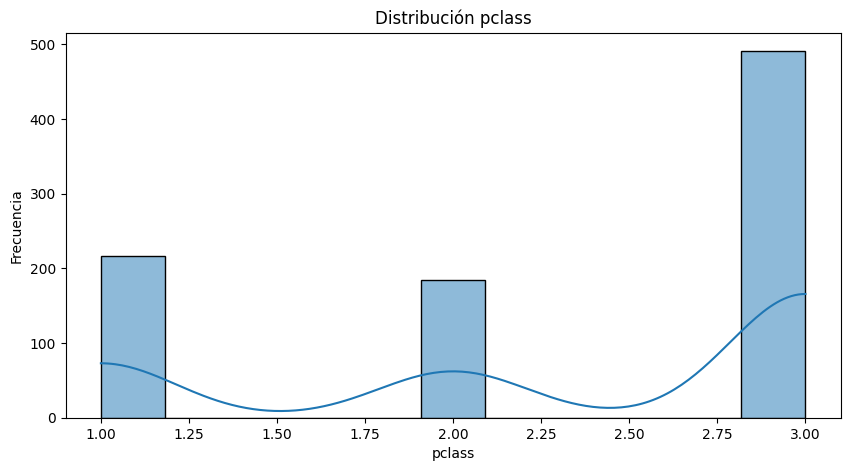

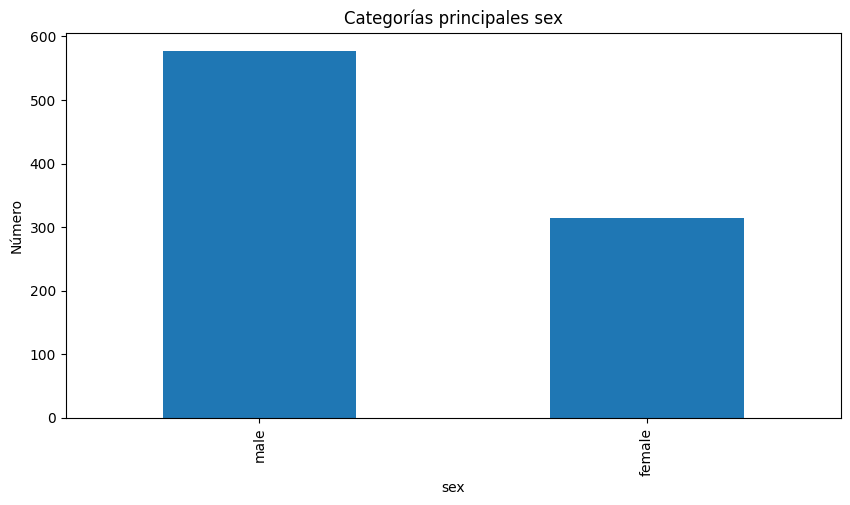

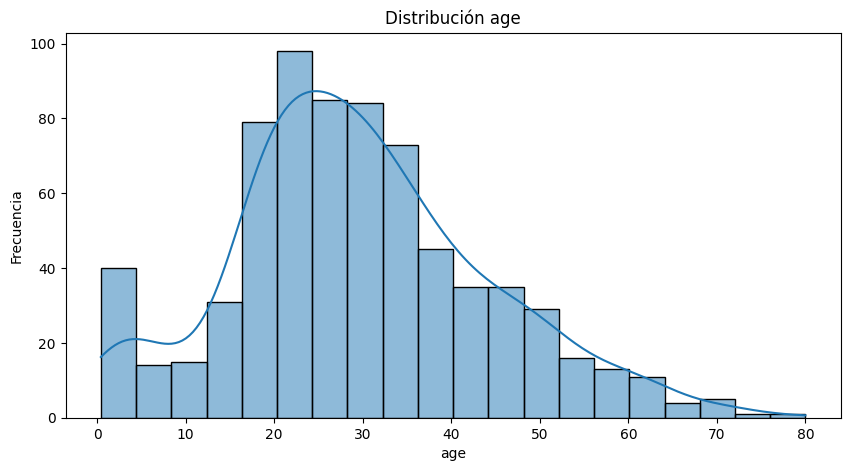

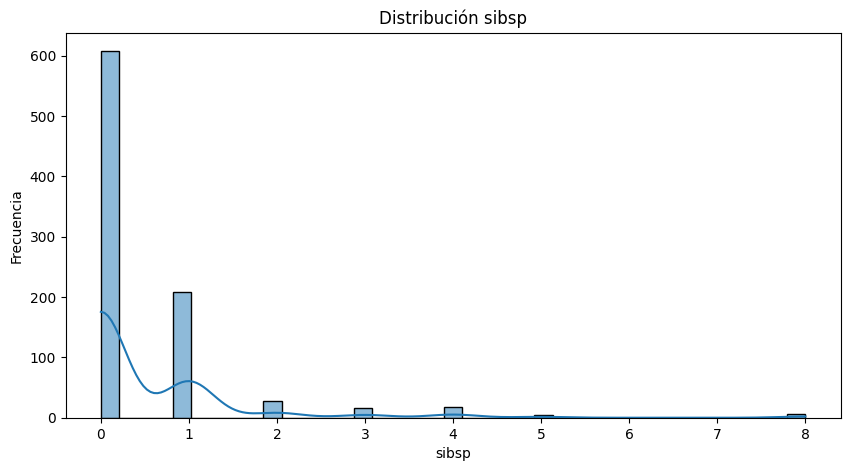

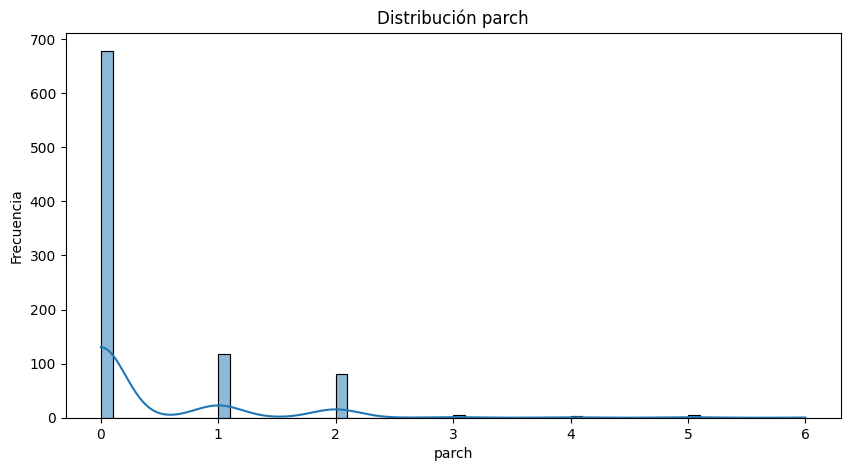

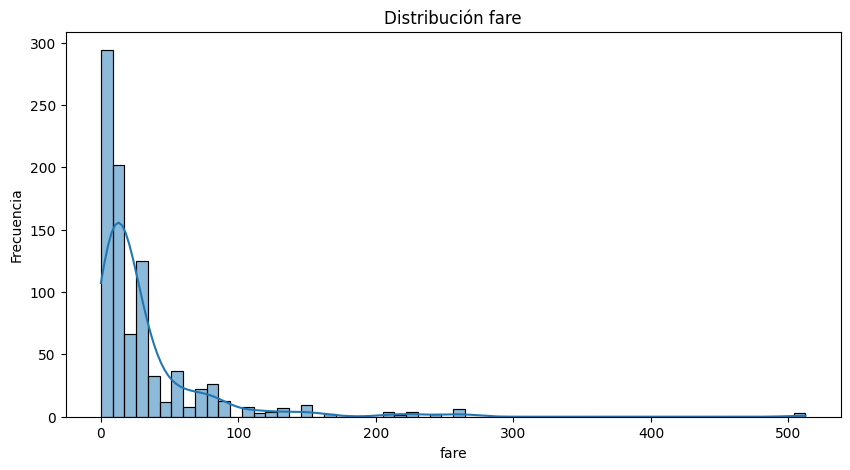

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_12692\1056790888.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_string_dtype(df[column]) or pd.api.types.is_categorical_dtype(df[column]):


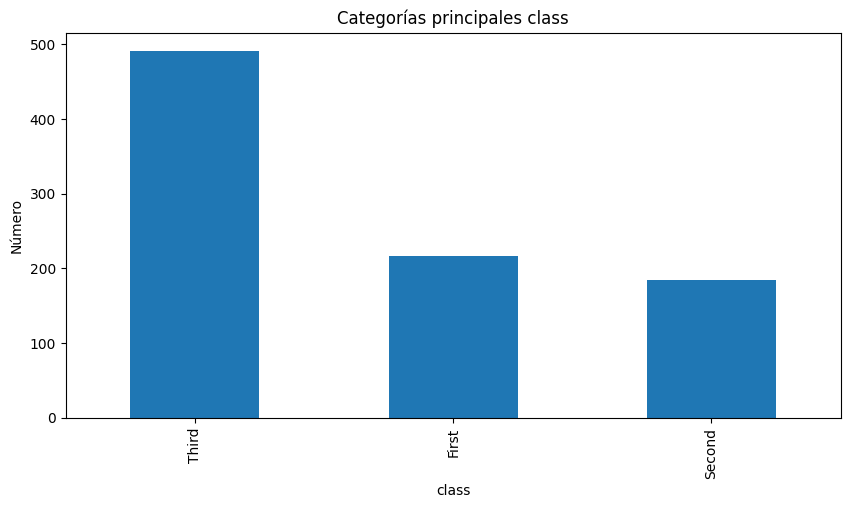

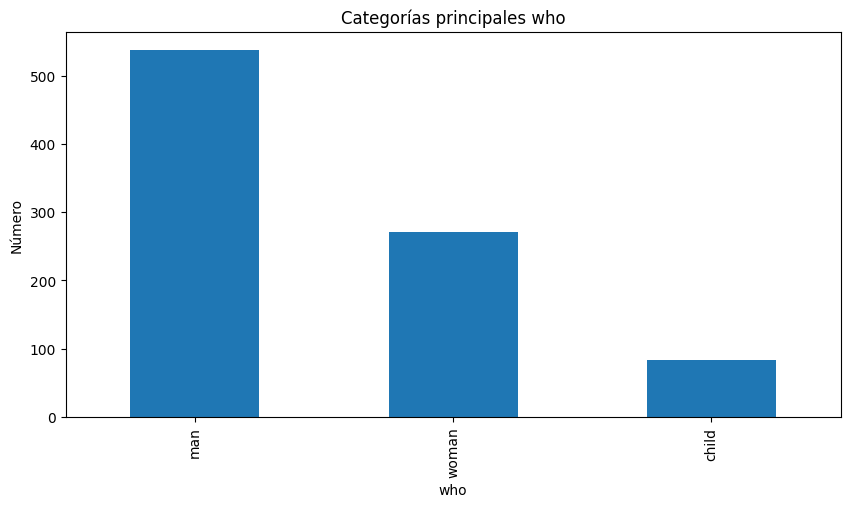

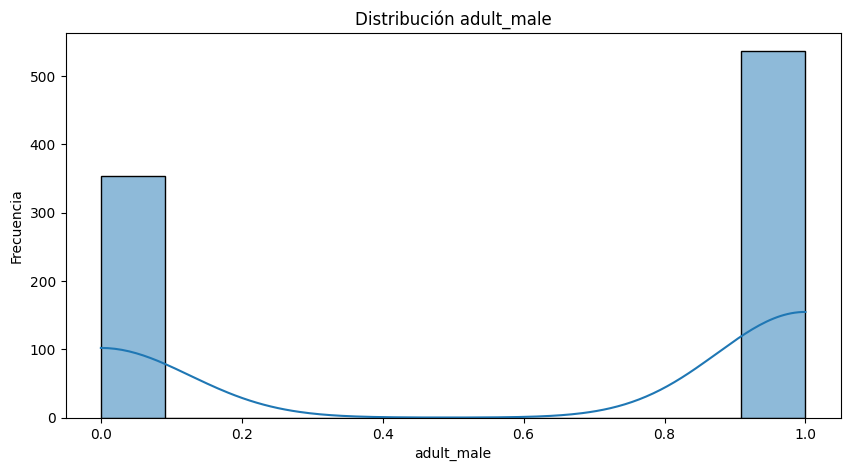

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_12692\1056790888.py:20: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_string_dtype(df[column]) or pd.api.types.is_categorical_dtype(df[column]):


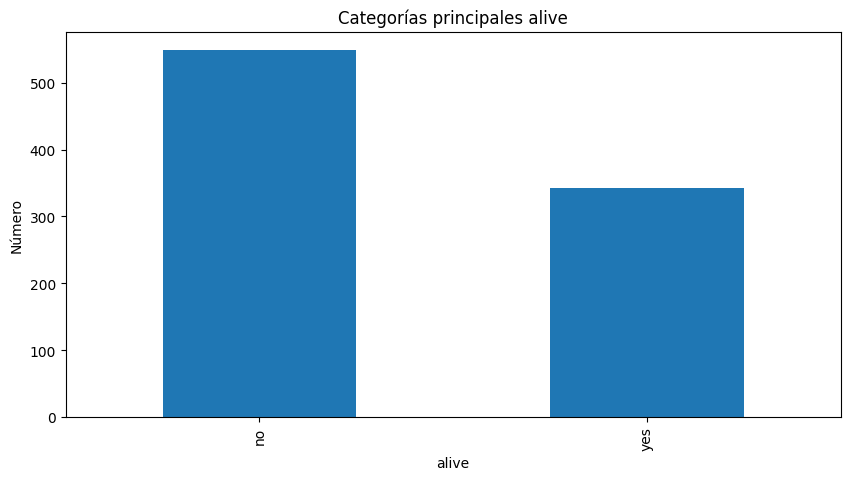

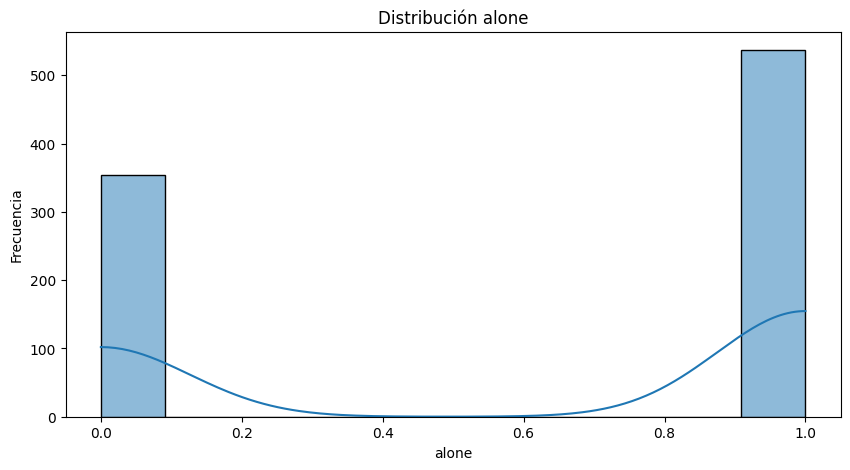

In [ ]:
df = pd.read_csv("titanic.csv")
auto_visualize_dataframe(df)